Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
=== LOGISTIC REGRESSION ===
Accuracy: 75.15 %
              precision    reca

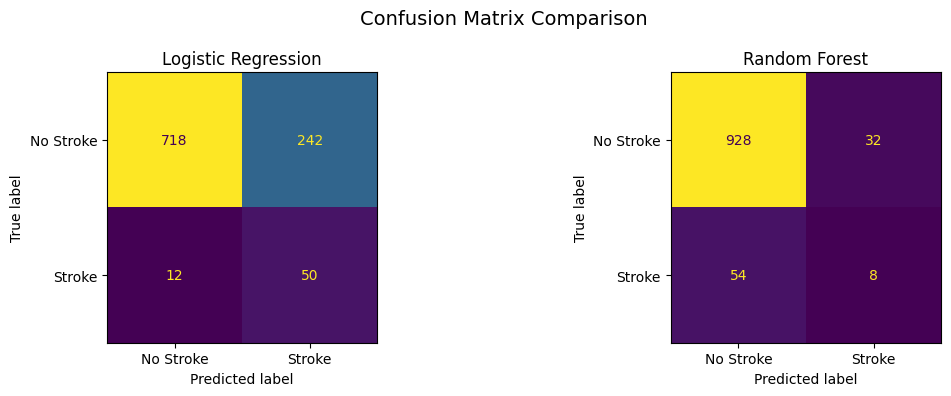

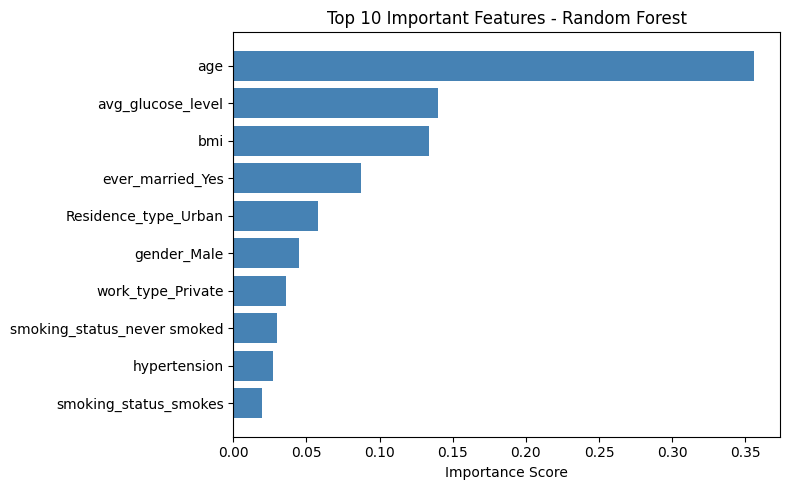

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()

df = df.drop("id", axis=1)
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
df = pd.get_dummies(df, drop_first=True)

X = df.drop("stroke", axis=1)
y = df["stroke"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test_scaled)

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

print("=== LOGISTIC REGRESSION ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")
print(classification_report(y_test, y_pred_lr))

print("=== RANDOM FOREST ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print(classification_report(y_test, y_pred_rf))


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["No Stroke","Stroke"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["No Stroke","Stroke"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()


feature_names = X.columns
importances = rf.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
!git clone https://github.com/sengar-kushh/Stroke-Prediction.git
%cd Stroke-Prediction

Cloning into 'Stroke-Prediction'...
/content/Stroke-Prediction


In [ ]:
!git config --global user.email "kushagrasengar2006@gmail.com"
!git config --global user.name "Kushagra Sengar"
# Your actual Python code goes here (without the ! prefix)
import pandas as pd
import numpy as np

# Your stroke prediction code
print("Starting stroke prediction project")

Starting stroke prediction project


In [ ]:
!git add .
!git commit -m "Add stroke prediction code from Colab"
!git push origin main

On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/sengar-kushh/Stroke-Prediction.git'


In [1]:
!pwd
!ls -la

/content
total 16
drwxr-xr-x 1 root root 4096 Jun  4 13:32 .
drwxr-xr-x 1 root root 4096 Jun 15 10:38 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data


In [2]:
%cd /content/Stroke-Prediction


[Errno 2] No such file or directory: '/content/Stroke-Prediction'
/content


In [3]:
!ls /content

sample_data


In [4]:
!git clone https://github.com/sengar-kushh/Stroke-Prediction.git

Cloning into 'Stroke-Prediction'...


In [5]:
%cd /content/Stroke-Prediction
!pwd

/content/Stroke-Prediction
/content/Stroke-Prediction


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!find /content/drive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Stroke Prediction.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Date 9 Jan.ipynb
/content/drive/MyDrive/Colab Notebooks/Date 7 jan ,2025.ipynb
/content/drive/MyDrive/Colab Notebooks/Date10Jan.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Linerar Regression.ipynb
/content/drive/MyDrive/Colab Notebooks/Linear Regression.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Stroke project.ipynb
/content/drive/MyDrive/Untitled6.ipynb


In [ ]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Stroke Prediction.ipynb",
    "/content/Stroke-Prediction/"
)